# III. Varying the params of the opinion spread models
The graph generating model is fixed, only the values of the opinion models' parameters are changed (always one at a time).

In [ ]:
import numpy as np

from rand_hypergraph_models import generate_general_er_hypergraph, generate_recursive_er_simplicial_complex
from opinion_spread_models import noisy_voter_step, adaptive_voter_step
from helper_functions import prepare_graph_for_simulation, generate_opinions
from run_simulations import absorbed_adaptive, absorbed_noisy
from analysis3 import estimate_consensus_and_majority_ratio, plot_consensus_and_majority_vs_parameter

In [2]:
N = 25 # simulations are reapeted N times
n= 100 # number of nodes
steps = 500 #number discrete time steps

prob_positive_opinion= 0.5 # Probability with what a node is of opinion +1 
ER_probabilites = {2: 0.15, 5: 0.00000133} # Probabilities for ER hypergraph generator
recursive_ER_kwargs = {
    "n": n,
    "p1": 0.15,
    "p2": 0.3,
}

p_values = np.linspace(0, 1, 50) # A discretization of the x-axis, these are the points at which we evaluate and run the simulations.
q_values = np.linspace(0, 1, 50) #  A discretization of the x-axis, these are the points at which we evaluate and run the simulations.

In [3]:
opinions = generate_opinions(n, prob_positive_opinion)
hypergraph = generate_general_er_hypergraph(n, ER_probabilites, opinions)
simplicial_complex = generate_recursive_er_simplicial_complex(n, 0.15, 0.3, opinions)

{np.float64(0.0): {'consensus_probability': np.float64(0.4), 'average_final_majority_ratio': np.float64(0.8689999999999999), 'average_final_inactive_edge_ratio': np.float64(0.8062380952380953)}, np.float64(0.02040816326530612): {'consensus_probability': np.float64(0.42), 'average_final_majority_ratio': np.float64(0.8453999999999999), 'average_final_inactive_edge_ratio': np.float64(0.7861190476190475)}, np.float64(0.04081632653061224): {'consensus_probability': np.float64(0.44), 'average_final_majority_ratio': np.float64(0.9014), 'average_final_inactive_edge_ratio': np.float64(0.8496666666666668)}, np.float64(0.061224489795918366): {'consensus_probability': np.float64(0.42), 'average_final_majority_ratio': np.float64(0.8382000000000001), 'average_final_inactive_edge_ratio': np.float64(0.7752857142857144)}, np.float64(0.08163265306122448): {'consensus_probability': np.float64(0.42), 'average_final_majority_ratio': np.float64(0.892), 'average_final_inactive_edge_ratio': np.float64(0.83285

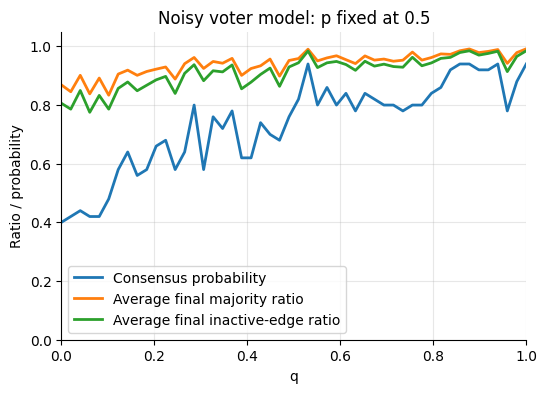

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Noisy voter model: p fixed at 0.5'}, xlabel='q', ylabel='Ratio / probability'>)

In [4]:
results_q_noisy = estimate_consensus_and_majority_ratio(
    base_graph=hypergraph,
    prepare_function=prepare_graph_for_simulation,
    step_function=noisy_voter_step,
    absorbed_function=absorbed_noisy,
    fixed_param_name="q",
    fixed_param_value=0.5,
    varying_param_name="p",
    varying_values=p_values,
    max_steps=steps,
    base_seed=123,
    extra_step_kwargs={}
)

print(results_q_noisy)

plot_consensus_and_majority_vs_parameter(
    results_q_noisy,
    varying_param_name="q",
    fixed_text="p fixed at 0.5",
    model_name="Noisy voter model"
)

{np.float64(0.0): {'consensus_probability': np.float64(0.38), 'average_final_majority_ratio': np.float64(0.8466000000000001), 'average_final_inactive_edge_ratio': np.float64(0.7850476190476191)}, np.float64(0.02040816326530612): {'consensus_probability': np.float64(0.36), 'average_final_majority_ratio': np.float64(0.8306), 'average_final_inactive_edge_ratio': np.float64(0.7585)}, np.float64(0.04081632653061224): {'consensus_probability': np.float64(0.48), 'average_final_majority_ratio': np.float64(0.8782), 'average_final_inactive_edge_ratio': np.float64(0.8210714285714286)}, np.float64(0.061224489795918366): {'consensus_probability': np.float64(0.58), 'average_final_majority_ratio': np.float64(0.9087999999999999), 'average_final_inactive_edge_ratio': np.float64(0.8573571428571429)}, np.float64(0.08163265306122448): {'consensus_probability': np.float64(0.64), 'average_final_majority_ratio': np.float64(0.9266), 'average_final_inactive_edge_ratio': np.float64(0.8867142857142857)}, np.floa

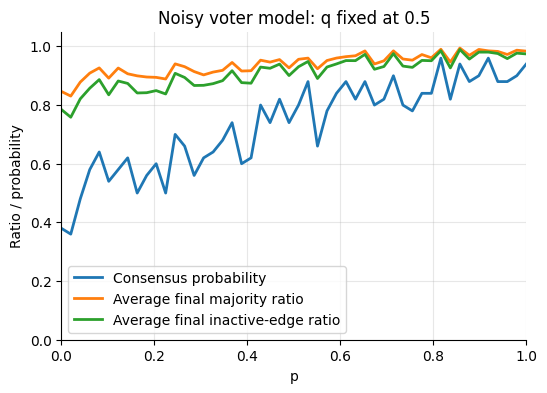

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Noisy voter model: q fixed at 0.5'}, xlabel='p', ylabel='Ratio / probability'>)

In [5]:
results_p_noisy = estimate_consensus_and_majority_ratio(
    base_graph=hypergraph,
    prepare_function=prepare_graph_for_simulation,
    step_function=noisy_voter_step,
    absorbed_function=absorbed_noisy,
    fixed_param_name="p",
    fixed_param_value=0.5,
    varying_param_name="q",
    varying_values=q_values,
    max_steps=steps,
    base_seed=123,
    extra_step_kwargs={}
)

print(results_p_noisy)

plot_consensus_and_majority_vs_parameter(
    results_p_noisy,
    varying_param_name="p",
    fixed_text="q fixed at 0.5",
    model_name="Noisy voter model"
)

{np.float64(0.0): {'consensus_probability': np.float64(0.0), 'average_final_majority_ratio': np.float64(0.56), 'average_final_inactive_edge_ratio': np.float64(0.922036375097521)}, np.float64(0.02040816326530612): {'consensus_probability': np.float64(0.0), 'average_final_majority_ratio': np.float64(0.5672), 'average_final_inactive_edge_ratio': np.float64(0.8854472644709206)}, np.float64(0.04081632653061224): {'consensus_probability': np.float64(0.0), 'average_final_majority_ratio': np.float64(0.5692), 'average_final_inactive_edge_ratio': np.float64(0.8404927247456111)}, np.float64(0.061224489795918366): {'consensus_probability': np.float64(0.0), 'average_final_majority_ratio': np.float64(0.5902), 'average_final_inactive_edge_ratio': np.float64(0.8220938034464297)}, np.float64(0.08163265306122448): {'consensus_probability': np.float64(0.0), 'average_final_majority_ratio': np.float64(0.5746000000000001), 'average_final_inactive_edge_ratio': np.float64(0.8133199522426153)}, np.float64(0.10

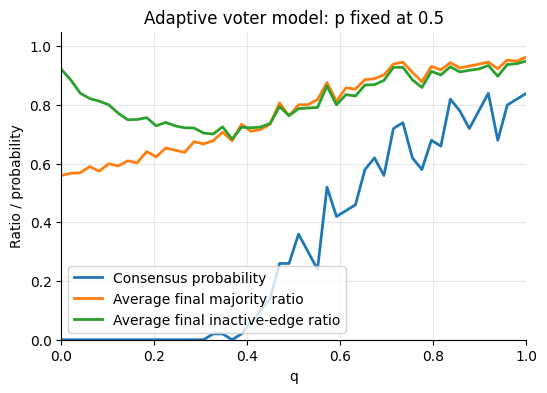

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Adaptive voter model: p fixed at 0.5'}, xlabel='q', ylabel='Ratio / probability'>)

In [6]:
results_q_adaptive = estimate_consensus_and_majority_ratio(
    base_graph=simplicial_complex,
    prepare_function=prepare_graph_for_simulation,
    step_function=adaptive_voter_step,
    absorbed_function=absorbed_adaptive,
    fixed_param_name="q",
    fixed_param_value=0.5,
    varying_param_name="p",
    varying_values=p_values,
    max_steps=steps,
    base_seed=123,
    extra_step_kwargs={"p_triangle": 0.3}
)

print(results_q_adaptive)

plot_consensus_and_majority_vs_parameter(
    results_q_adaptive,
    varying_param_name="q",
    fixed_text="p fixed at 0.5",
    model_name="Adaptive voter model"
)

{np.float64(0.0): {'consensus_probability': np.float64(0.0), 'average_final_majority_ratio': np.float64(0.6196), 'average_final_inactive_edge_ratio': np.float64(0.6147467809278971)}, np.float64(0.02040816326530612): {'consensus_probability': np.float64(0.0), 'average_final_majority_ratio': np.float64(0.6014), 'average_final_inactive_edge_ratio': np.float64(0.5959267726160065)}, np.float64(0.04081632653061224): {'consensus_probability': np.float64(0.02), 'average_final_majority_ratio': np.float64(0.6372000000000001), 'average_final_inactive_edge_ratio': np.float64(0.6245731377427189)}, np.float64(0.061224489795918366): {'consensus_probability': np.float64(0.0), 'average_final_majority_ratio': np.float64(0.6186), 'average_final_inactive_edge_ratio': np.float64(0.6142993063255044)}, np.float64(0.08163265306122448): {'consensus_probability': np.float64(0.0), 'average_final_majority_ratio': np.float64(0.6398), 'average_final_inactive_edge_ratio': np.float64(0.6257421970999221)}, np.float64(

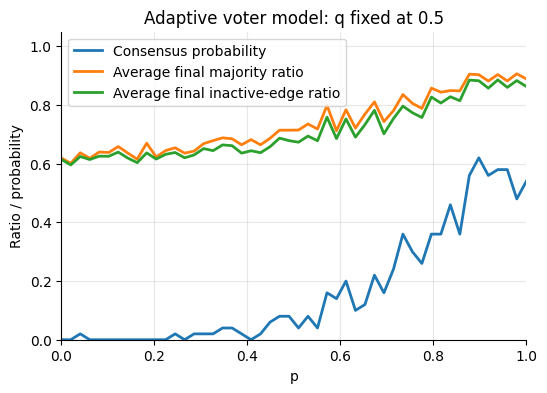

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Adaptive voter model: q fixed at 0.5'}, xlabel='p', ylabel='Ratio / probability'>)

In [7]:
results_p_adaptive = estimate_consensus_and_majority_ratio(
    base_graph=simplicial_complex,
    prepare_function=prepare_graph_for_simulation,
    step_function=adaptive_voter_step,
    absorbed_function=absorbed_adaptive,
    fixed_param_name="p",
    fixed_param_value=0.5,
    varying_param_name="q",
    varying_values=q_values,
    max_steps=steps,
    base_seed=123,
    extra_step_kwargs={}
)

print(results_p_adaptive)

plot_consensus_and_majority_vs_parameter(
    results_p_adaptive,
    varying_param_name="p",
    fixed_text="q fixed at 0.5",
    model_name="Adaptive voter model"
)